***LSTM vs GRU Comparision for Sentiment Analysis***

In [102]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [103]:
texts=[
    "I love deep learning",
    "Artificial Intelligence is amazing",
    "This course is excellent",
    "I am very happy today",
    "The movie was fantastic",
    "I hate this product",
    "This is very bad",
    "The service was terrible",
    "I am disappointed",
    "The experience was awful"
]
labels=[1,1,1,1,1,0,0,0,0,0]

In [104]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(texts)
sequences=tokenizer.texts_to_sequences(texts)
max_length=max(len(seq) for seq in sequences)
X=pad_sequences(sequences,maxlen=max_length)
y=np.array(labels)
print("X=",X)
print("y=",y)


X= [[ 0  1  8  9 10]
 [ 0 11 12  2 13]
 [ 0  3 14  2 15]
 [ 1  6  7 16 17]
 [ 0  4 18  5 19]
 [ 0  1 20  3 21]
 [ 0  3  2  7 22]
 [ 0  4 23  5 24]
 [ 0  0  1  6 25]
 [ 0  4 26  5 27]]
y= [1 1 1 1 1 0 0 0 0 0]


In [105]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

***LSTM Model***

In [106]:
lstm_model = Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index) + 1,
        output_dim=16,
        input_length=max_length
    ),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

In [87]:
lstm_model.compile(
    optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy']
                   )
lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [88]:
history_lstm=lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test,y_test),
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.6250 - loss: 0.6924 - val_accuracy: 0.5000 - val_loss: 0.6951
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step - accuracy: 0.6250 - loss: 0.6918 - val_accuracy: 0.5000 - val_loss: 0.6953
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.6250 - loss: 0.6911 - val_accuracy: 0.5000 - val_loss: 0.6955
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7500 - loss: 0.6905 - val_accuracy: 0.5000 - val_loss: 0.6957
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.8750 - loss: 0.6898 - val_accuracy: 0.5000 - val_loss: 0.6960
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8750 - loss: 0.6890 - val_accuracy: 0.0000e+00 - val_loss: 0.6963
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8750 - loss: 0.6882 - val_accuracy: 0.0000e+00 - val_loss: 0.6966
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8750 - loss: 0.6873 - val_accuracy: 0.5000 - val_lo

***GRU Model***

In [89]:
gru_model=Sequential([
    Embedding(
        input_dim=len(tokenizer.word_index)+1,
        output_dim=16,
        input_length=max_length
    ),
    GRU(32),
    Dense(1,activation='sigmoid')
])

In [90]:
gru_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [91]:
history_gru = gru_model.fit(
    X_train,
    y_train,
    epochs=20,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - accuracy: 0.3750 - loss: 0.6944 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.3750 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.3750 - loss: 0.6925 - val_accuracy: 0.5000 - val_loss: 0.6927
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6250 - loss: 0.6916 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.6250 - loss: 0.6907 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7500 - loss: 0.6898 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8750 - loss: 0.6889 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8750 - loss: 0.6879 - val_accuracy: 0.5000 - val_loss: 0.6

In [92]:
gru_loss, gru_accuracy = gru_model.evaluate(X_test, y_test)

print("GRU Test Accuracy:", gru_accuracy)
print("GRU Test Loss:", gru_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5000 - loss: 0.6993
GRU Test Accuracy: 0.5
GRU Test Loss: 0.6993041038513184


In [93]:
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test, y_test)

print("LSTM Test Accuracy:", lstm_accuracy)
print("LSTM Test Loss:", lstm_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5000 - loss: 0.7039
LSTM Test Accuracy: 0.5
LSTM Test Loss: 0.7039057016372681


In [94]:
print("\nModel Comparison")
print("--------------------------")
print("LSTM Accuracy:", lstm_accuracy)
print("GRU Accuracy :", gru_accuracy)
print("LSTM Loss    :", lstm_loss)
print("GRU Loss     :", gru_loss)


Model Comparison
--------------------------
LSTM Accuracy: 0.5
GRU Accuracy : 0.5
LSTM Loss    : 0.7039057016372681
GRU Loss     : 0.6993041038513184


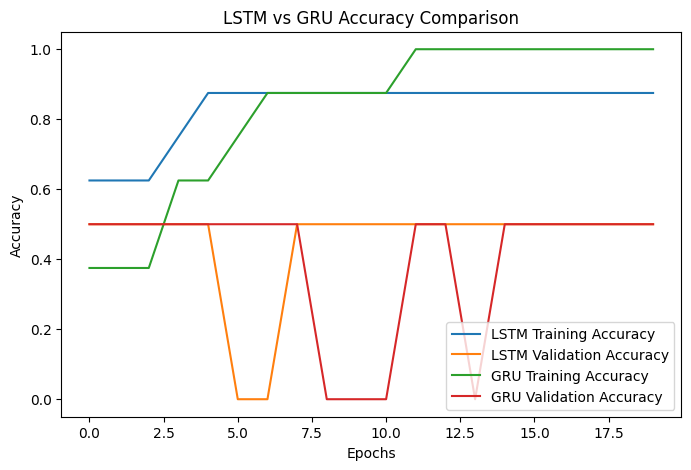

In [95]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['accuracy'], label='LSTM Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Validation Accuracy')
plt.plot(history_gru.history['accuracy'], label='GRU Training Accuracy')
plt.plot(history_gru.history['val_accuracy'], label='GRU Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('LSTM vs GRU Accuracy Comparison')
plt.legend()
plt.show()

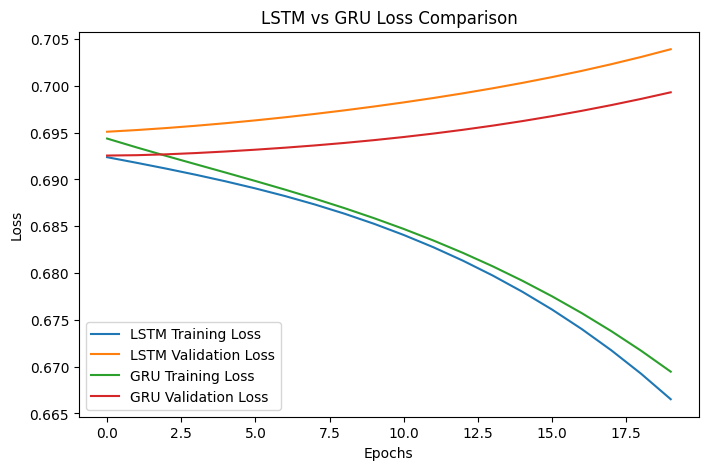

In [96]:
plt.figure(figsize=(8,5))
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss')
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss')
plt.plot(history_gru.history['loss'], label='GRU Training Loss')
plt.plot(history_gru.history['val_loss'], label='GRU Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('LSTM vs GRU Loss Comparison')
plt.legend()
plt.show()

In [97]:
def predict_sentiment(model, text):
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_length)

    prediction = model.predict(padded, verbose=0)[0][0]

    if prediction >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment, prediction

In [98]:
text = "I love Artificial Intelligence"
result, score = predict_sentiment(
    lstm_model,
    text
)

print("LSTM Prediction:")
print("Sentiment:", result)
print("Score:", score)

LSTM Prediction:
Sentiment: Positive
Score: 0.5061431


In [99]:
text = "This is very bad"
result, score = predict_sentiment(
    lstm_model,
    text
)

print("LSTM Prediction:")
print("Sentiment:", result)
print("Score:", score)

LSTM Prediction:
Sentiment: Negative
Score: 0.48447645


In [100]:
text="I Love Artificial Intelligence"
result, score = predict_sentiment(
    gru_model,
    text
)

print("GRU Prediction:")
print("Sentiment:", result)
print("Score:", score)

GRU Prediction:
Sentiment: Positive
Score: 0.5029441


In [101]:
text = "This is very bad"
result, score = predict_sentiment(
    gru_model,
    text
)

print("GRU Prediction:")
print("Sentiment:", result)
print("Score:", score)

GRU Prediction:
Sentiment: Negative
Score: 0.48449236
